CONFIGURATION
Device: 0
GPU: Tesla T4
FOUND: Original dangerous-person dataset
       /kaggle/input/datasets/abirbot69/dangerous-23
FOUND: Bag dataset
       /kaggle/input/datasets/abirbot69/bag-person-dataset
FOUND: Phone dataset
       /kaggle/input/datasets/abirbot69/phone-perrson-dataset
FOUND: Previous model
       /kaggle/input/datasets/abirbot69/yolov23/best_dangerous_person_yolo11s.pt

Copying original dataset to /kaggle/working...
Writable dataset created:
/kaggle/working/hard_negative_project/combined_dataset

Dataset splits:
Train: /kaggle/working/hard_negative_project/combined_dataset/train
Valid: /kaggle/working/hard_negative_project/combined_dataset/valid
Test : /kaggle/working/hard_negative_project/combined_dataset/test

Annotation repairs: 1

Bag classes: ['backpack', 'handbag', 'person']
Bag person class ID: 2

Processing 1000 bag images...
Bag progress: 200/1000
Bag progress: 400/1000
Bag progress: 600/1000
Bag progress: 800/1000
Bag progress: 1000/1000

Bag images ad

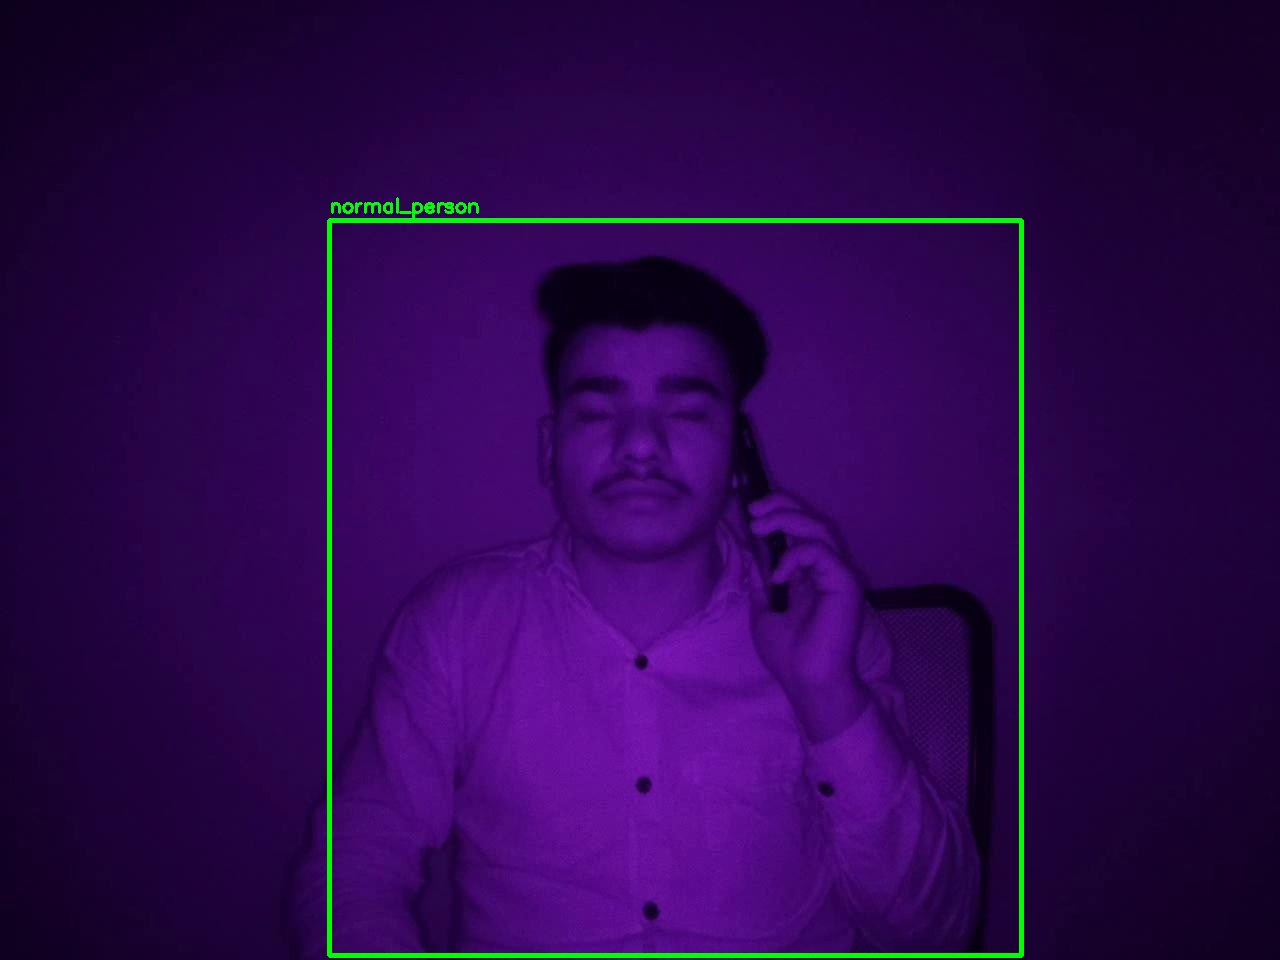

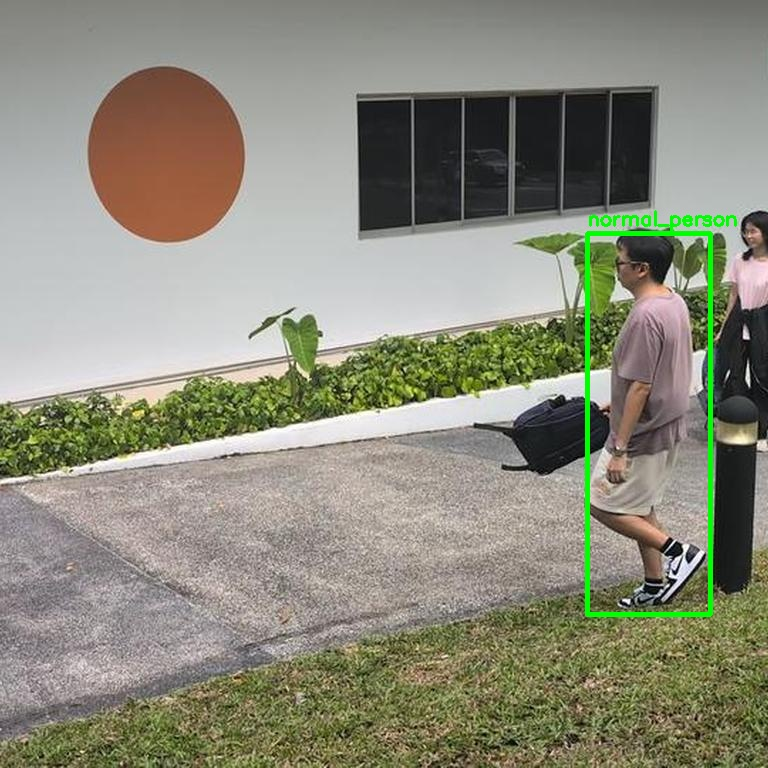

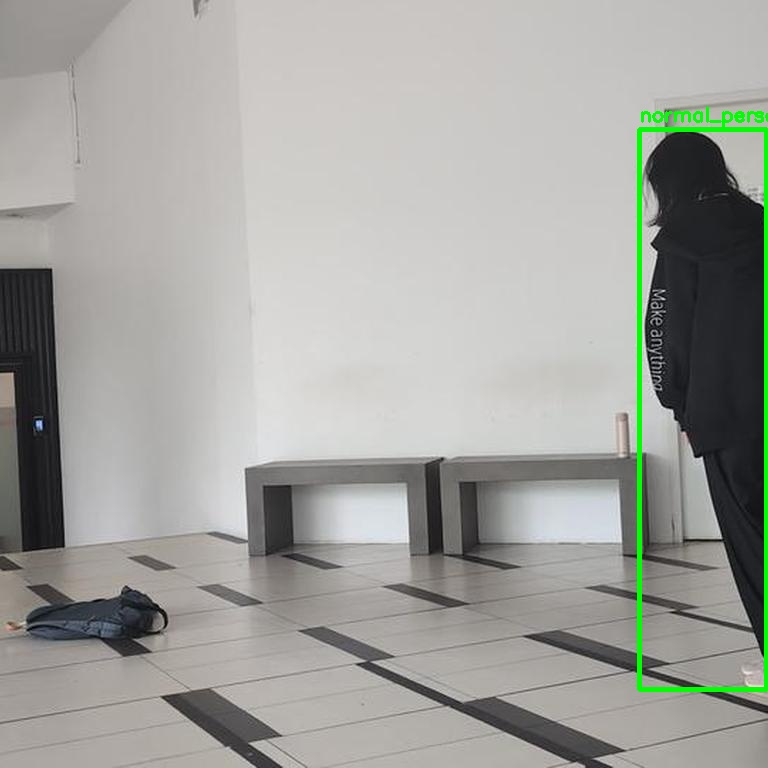

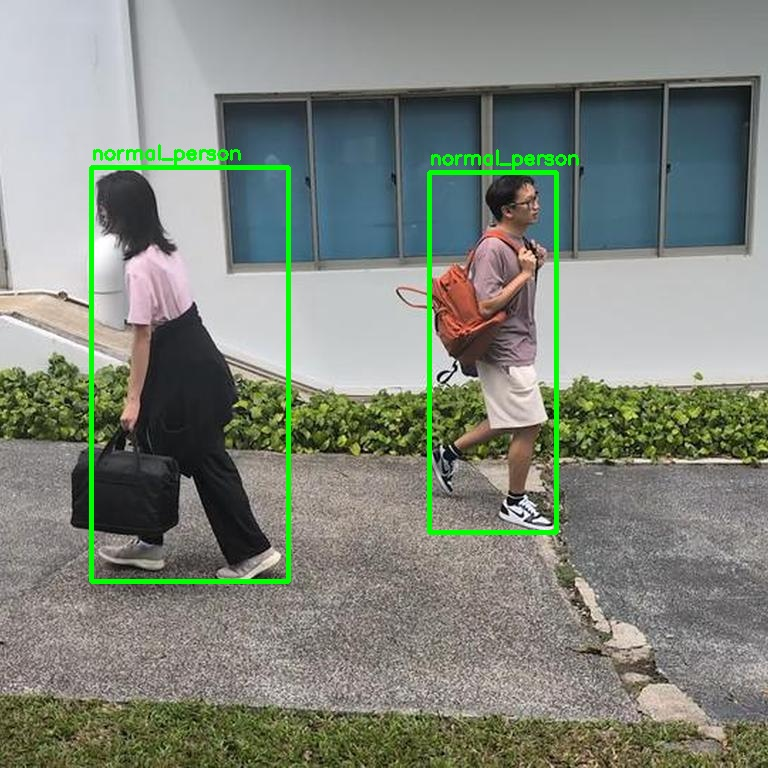

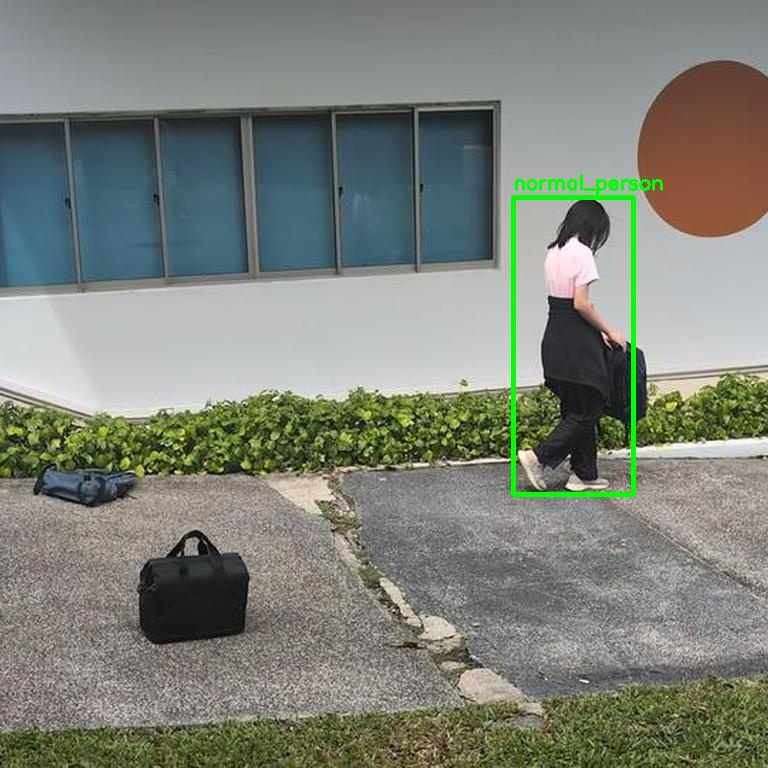

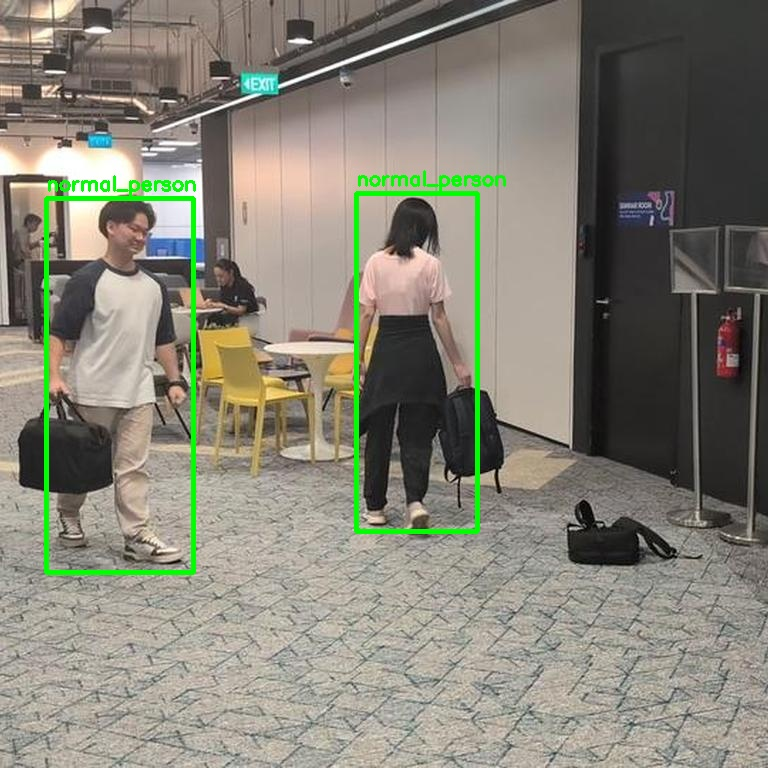

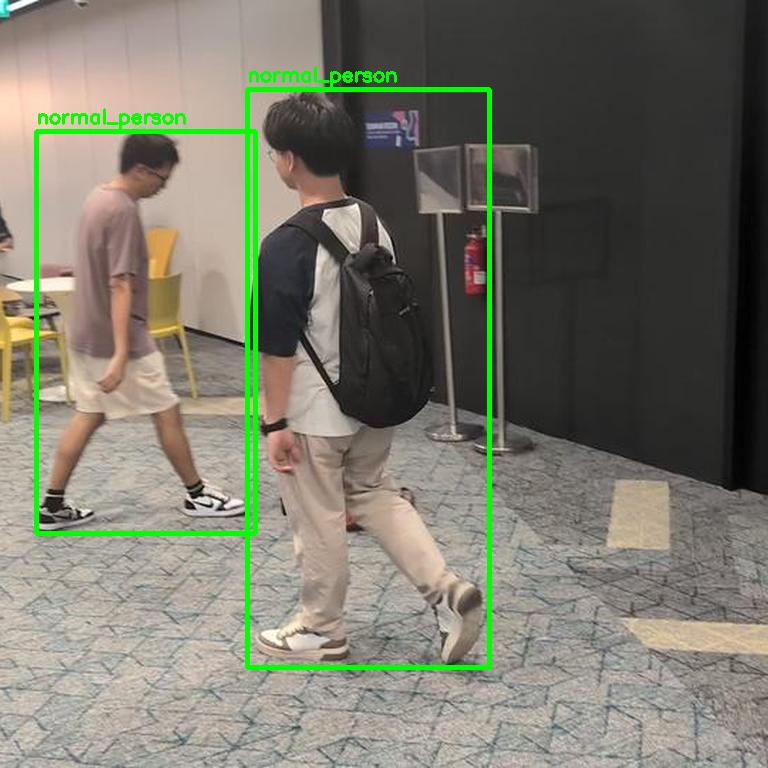

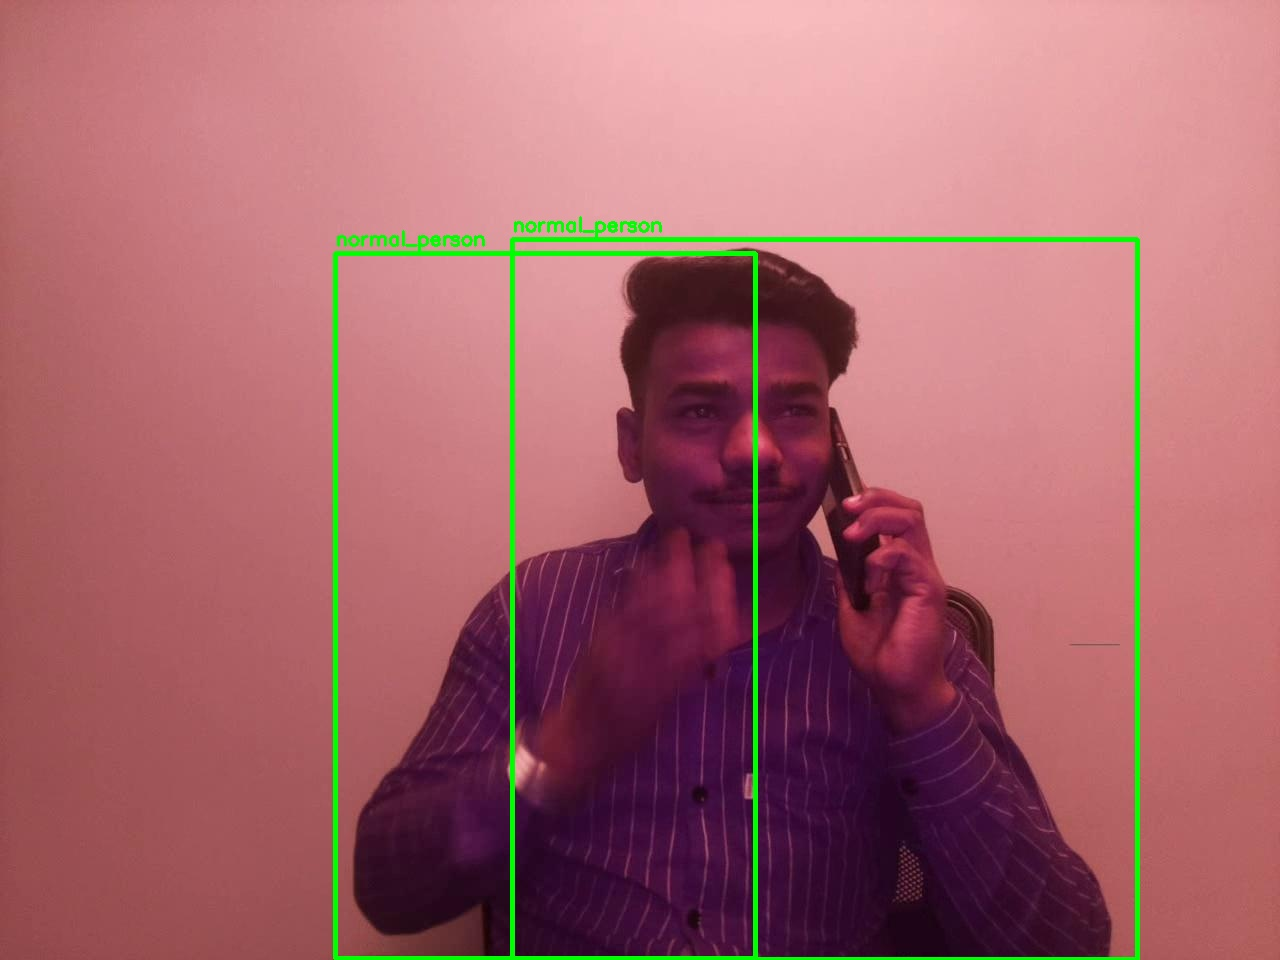

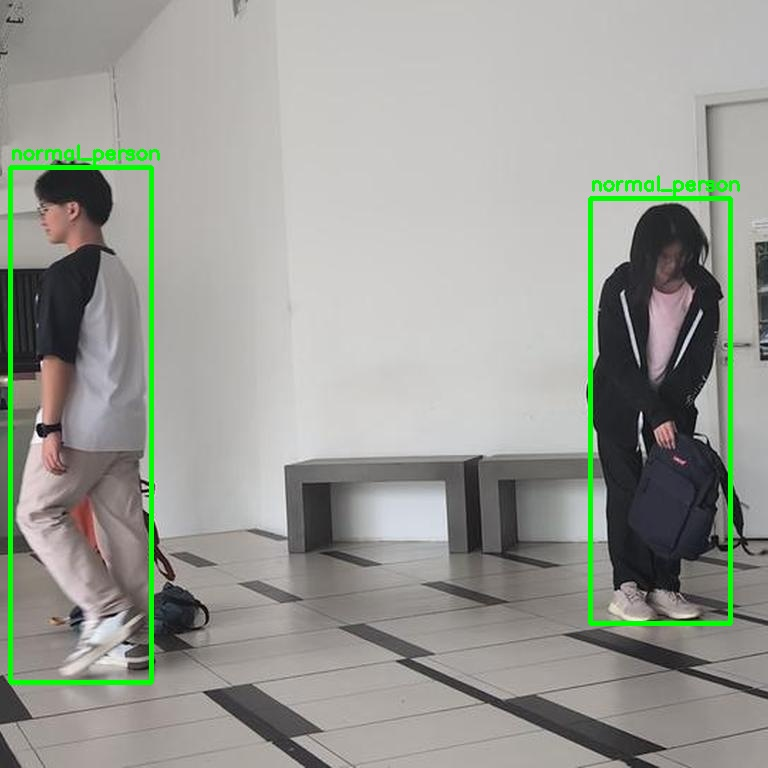

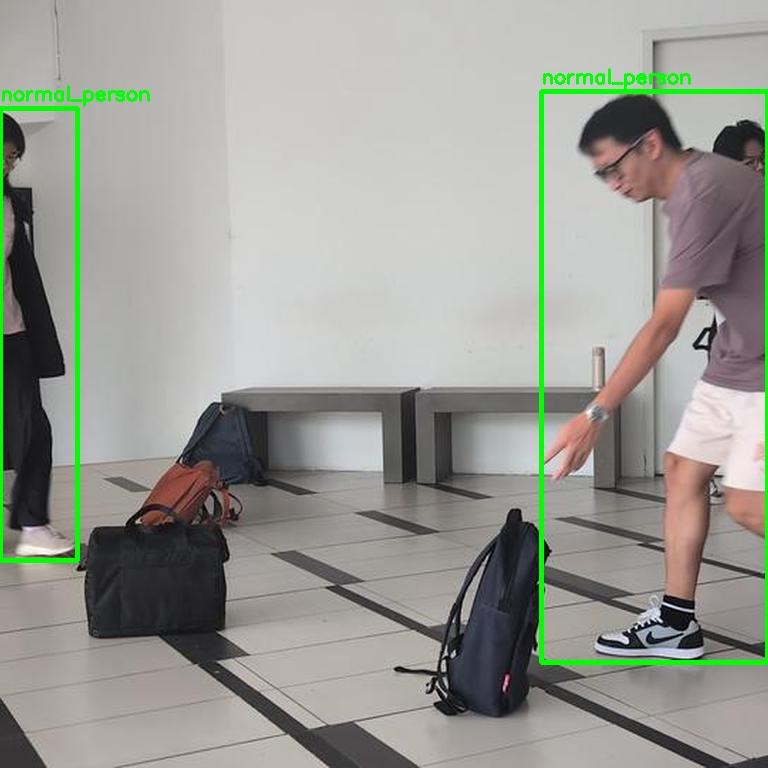


GPU memory before training:
Allocated: 4.64 GB
Reserved: 4.65 GB

STARTING HARD-NEGATIVE FINE-TUNING
Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/hard_negative_project/phone_bag_hard_negative_data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_d

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      6.76G     0.9798     0.7156      1.149         64        640: 100% ━━━━━━━━━━━━ 524/524 8.6it/s 1:010.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 8.3it/s 2.4s0.1s
                   all        314       1324      0.884      0.786      0.878      0.496

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      6.78G     0.9619     0.7081      1.146         24        640: 100% ━━━━━━━━━━━━ 524/524 8.6it/s 1:010.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 8.2it/s 2.4s0.1s
                   all        314       1324      0.898      0.768      0.868      0.534

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      6.77G     0.9439     0.6837       1.13         12        640: 100% ━━━━━━━━━━━━ 524/524 8.6it/s 1:010.1sss
                 Class     Ima

In [4]:
# ================================================================
# YOLO11 DANGEROUS-PERSON HARD-NEGATIVE FINE-TUNING
# MEMORY-SAFE KAGGLE VERSION
#
# Class 0 = normal_person
# Class 1 = potentially_dangerous_person
# ================================================================

!pip install -q -U ultralytics pyyaml

import gc
import cv2
import yaml
import json
import shutil
import random
import zipfile
import uuid
import torch

from pathlib import Path
from collections import Counter
from ultralytics import YOLO
from IPython.display import display, Image as IPImage


# ================================================================
# 1. INPUT PATHS
# ================================================================

ORIGINAL_DATASET = Path(
    "/kaggle/input/datasets/abirbot69/dangerous-23"
)

BAG_DATASET = Path(
    "/kaggle/input/datasets/abirbot69/bag-person-dataset"
)

PHONE_DATASET = Path(
    "/kaggle/input/datasets/abirbot69/phone-perrson-dataset"
)

PREVIOUS_MODEL = Path(
    "/kaggle/input/datasets/abirbot69/yolov23/"
    "best_dangerous_person_yolo11s.pt"
)


# ================================================================
# 2. OUTPUT PATHS
# ================================================================

WORK_ROOT = Path(
    "/kaggle/working/hard_negative_project"
)

COMBINED_DATASET = (
    WORK_ROOT / "combined_dataset"
)

RUNS_DIRECTORY = Path(
    "/kaggle/working/hard_negative_training"
)

EVALUATION_DIRECTORY = Path(
    "/kaggle/working/hard_negative_evaluation"
)

FINAL_MODEL = Path(
    "/kaggle/working/"
    "best_phone_bag_hard_negative_yolo11s.pt"
)

FINAL_METRICS = Path(
    "/kaggle/working/"
    "phone_bag_hard_negative_metrics.json"
)

FINAL_ZIP = Path(
    "/kaggle/working/"
    "phone_bag_hard_negative_results.zip"
)


# ================================================================
# 3. SETTINGS
# ================================================================

MAX_BAG_IMAGES = 1000
MAX_PHONE_IMAGES = 1000

PSEUDO_LABEL_CONFIDENCE = 0.25
PSEUDO_LABEL_IOU = 0.50

EPOCHS = 50
IMAGE_SIZE = 640

# Reduced from 16 to avoid GPU memory errors.
BATCH_SIZE = 8

WORKERS = 2
SEED = 42

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp", ".tif", ".tiff"
}

random.seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. Training will be very slow.")


# ================================================================
# 4. VERIFY INPUT PATHS
# ================================================================

required_paths = {
    "Original dangerous-person dataset": ORIGINAL_DATASET,
    "Bag dataset": BAG_DATASET,
    "Phone dataset": PHONE_DATASET,
    "Previous model": PREVIOUS_MODEL
}

for description, path in required_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"\n{description} was not found:\n{path}\n\n"
            "Check the Kaggle Input panel."
        )

    print(f"FOUND: {description}")
    print(f"       {path}")


# ================================================================
# 5. HELPER FUNCTIONS
# ================================================================

def read_yaml(path):

    with open(path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


def normalize_names(names):

    if isinstance(names, dict):

        return [
            names[key]
            for key in sorted(
                names,
                key=lambda item: int(item)
            )
        ]

    return list(names)


def get_all_images(root):

    return sorted([
        path
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ])


def locate_split(root, possible_names):

    for name in possible_names:

        split = root / name

        if (split / "images").exists():
            return split

    for images_directory in root.rglob("images"):

        if images_directory.parent.name.lower() in possible_names:
            return images_directory.parent

    return None


def find_dataset_yaml(root):

    direct_yaml = root / "data.yaml"

    if direct_yaml.exists():
        return direct_yaml

    yaml_files = list(root.rglob("data.yaml"))

    if yaml_files:
        return yaml_files[0]

    return None


def find_label_for_image(image_path):

    candidates = [
        image_path.with_suffix(".txt"),

        Path(
            str(image_path).replace(
                "/images/",
                "/labels/"
            )
        ).with_suffix(".txt"),

        image_path.parent.parent
        / "labels"
        / f"{image_path.stem}.txt"
    ]

    for candidate in candidates:

        if candidate.exists():
            return candidate

    return None


def parse_yolo_line(line):

    parts = line.strip().split()

    if len(parts) != 5:
        return None

    try:
        class_id = int(float(parts[0]))
        x, y, width, height = map(float, parts[1:])

    except (ValueError, TypeError):
        return None

    values = [x, y, width, height]

    # Reject NaN and infinity.
    if not all(
        value == value and abs(value) != float("inf")
        for value in values
    ):
        return None

    # Allow very small annotation errors by clipping.
    x = max(0.0, min(1.0, x))
    y = max(0.0, min(1.0, y))
    width = max(0.0, min(1.0, width))
    height = max(0.0, min(1.0, height))

    if width <= 0 or height <= 0:
        return None

    return class_id, x, y, width, height


def format_yolo_line(
    class_id,
    x,
    y,
    width,
    height
):

    return (
        f"{class_id} "
        f"{x:.6f} "
        f"{y:.6f} "
        f"{width:.6f} "
        f"{height:.6f}"
    )


def create_unique_name(prefix, image_path):

    identifier = uuid.uuid4().hex[:10]

    return (
        f"{prefix}_"
        f"{image_path.stem}_"
        f"{identifier}"
    )


def clear_memory():

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ================================================================
# 6. CREATE WRITABLE DATASET COPY
# ================================================================

clear_memory()

if WORK_ROOT.exists():
    shutil.rmtree(WORK_ROOT)

if RUNS_DIRECTORY.exists():
    shutil.rmtree(RUNS_DIRECTORY)

if EVALUATION_DIRECTORY.exists():
    shutil.rmtree(EVALUATION_DIRECTORY)

WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

RUNS_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

EVALUATION_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

print("\nCopying original dataset to /kaggle/working...")

shutil.copytree(
    ORIGINAL_DATASET,
    COMBINED_DATASET
)

print("Writable dataset created:")
print(COMBINED_DATASET)


# ================================================================
# 7. LOCATE DATASET SPLITS
# ================================================================

train_split = locate_split(
    COMBINED_DATASET,
    ["train"]
)

valid_split = locate_split(
    COMBINED_DATASET,
    ["valid", "val"]
)

test_split = locate_split(
    COMBINED_DATASET,
    ["test"]
)

if train_split is None:
    raise FileNotFoundError(
        "Could not find train/images."
    )

if valid_split is None:
    raise FileNotFoundError(
        "Could not find valid/images or val/images."
    )

if test_split is None:
    raise FileNotFoundError(
        "Could not find test/images."
    )

train_images_directory = train_split / "images"
train_labels_directory = train_split / "labels"

valid_images_directory = valid_split / "images"
valid_labels_directory = valid_split / "labels"

test_images_directory = test_split / "images"
test_labels_directory = test_split / "labels"

for directory in [
    train_labels_directory,
    valid_labels_directory,
    test_labels_directory
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("\nDataset splits:")
print("Train:", train_split)
print("Valid:", valid_split)
print("Test :", test_split)


# ================================================================
# 8. REPAIR ORIGINAL ANNOTATIONS
# ================================================================
# Only the writable copy is modified.
# Kaggle /input remains unchanged.
# ================================================================

repair_log = []

split_information = [
    (
        "train",
        train_images_directory,
        train_labels_directory
    ),
    (
        "valid",
        valid_images_directory,
        valid_labels_directory
    ),
    (
        "test",
        test_images_directory,
        test_labels_directory
    )
]

for (
    split_name,
    images_directory,
    labels_directory
) in split_information:

    images = sorted([
        path
        for path in images_directory.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in images:

        label_path = (
            labels_directory
            / f"{image_path.stem}.txt"
        )

        # Create empty labels for background images.
        if not label_path.exists():

            label_path.write_text(
                "",
                encoding="utf-8"
            )

            repair_log.append({
                "split": split_name,
                "file": str(label_path),
                "action": "created_empty_label"
            })

            continue

        original_lines = label_path.read_text(
            encoding="utf-8",
            errors="ignore"
        ).splitlines()

        repaired_lines = []

        for line_number, line in enumerate(
            original_lines,
            start=1
        ):

            if not line.strip():
                continue

            parsed = parse_yolo_line(line)

            if parsed is None:

                repair_log.append({
                    "split": split_name,
                    "file": str(label_path),
                    "line": line_number,
                    "content": line,
                    "action": "removed_invalid_annotation"
                })

                continue

            class_id, x, y, width, height = parsed

            if class_id not in [0, 1]:

                repair_log.append({
                    "split": split_name,
                    "file": str(label_path),
                    "line": line_number,
                    "content": line,
                    "action": "removed_invalid_class"
                })

                continue

            repaired_lines.append(
                format_yolo_line(
                    class_id,
                    x,
                    y,
                    width,
                    height
                )
            )

        repaired_content = (
            "\n".join(repaired_lines) + "\n"
            if repaired_lines
            else ""
        )

        label_path.write_text(
            repaired_content,
            encoding="utf-8"
        )

print("\nAnnotation repairs:", len(repair_log))


# ================================================================
# 9. FIND PERSON CLASS IN BAG DATASET
# ================================================================

bag_yaml_path = find_dataset_yaml(BAG_DATASET)

if bag_yaml_path:

    bag_yaml = read_yaml(bag_yaml_path)

    bag_class_names = normalize_names(
        bag_yaml.get("names", [])
    )

else:

    bag_class_names = [
        "backpack",
        "handbag",
        "person"
    ]

print("\nBag classes:", bag_class_names)

bag_person_class = None

for class_id, class_name in enumerate(
    bag_class_names
):

    if str(class_name).strip().lower() == "person":
        bag_person_class = class_id
        break

if bag_person_class is None:

    print(
        "Person class was not found in the YAML. "
        "Using class 2."
    )

    bag_person_class = 2

print("Bag person class ID:", bag_person_class)


# ================================================================
# 10. ADD BAG PEOPLE AS NORMAL_PERSON
# ================================================================

all_bag_images = get_all_images(BAG_DATASET)

random.shuffle(all_bag_images)

selected_bag_images = all_bag_images[
    :min(MAX_BAG_IMAGES, len(all_bag_images))
]

bag_images_added = 0
bag_person_boxes_added = 0
bag_images_skipped = 0

print(
    f"\nProcessing {len(selected_bag_images)} "
    "bag images..."
)

for image_number, image_path in enumerate(
    selected_bag_images,
    start=1
):

    label_path = find_label_for_image(image_path)

    if label_path is None:

        bag_images_skipped += 1
        continue

    source_lines = label_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    person_lines = []

    for line in source_lines:

        parsed = parse_yolo_line(line)

        if parsed is None:
            continue

        class_id, x, y, width, height = parsed

        # Keep full-person boxes only.
        if class_id != bag_person_class:
            continue

        # Convert to class 0 = normal_person.
        person_lines.append(
            format_yolo_line(
                0,
                x,
                y,
                width,
                height
            )
        )

    if not person_lines:

        bag_images_skipped += 1
        continue

    new_stem = create_unique_name(
        "bag_normal",
        image_path
    )

    destination_image = (
        train_images_directory
        / f"{new_stem}{image_path.suffix.lower()}"
    )

    destination_label = (
        train_labels_directory
        / f"{new_stem}.txt"
    )

    shutil.copy2(
        image_path,
        destination_image
    )

    destination_label.write_text(
        "\n".join(person_lines) + "\n",
        encoding="utf-8"
    )

    bag_images_added += 1
    bag_person_boxes_added += len(person_lines)

    if image_number % 200 == 0:

        print(
            f"Bag progress: {image_number}/"
            f"{len(selected_bag_images)}"
        )

print("\nBag images added:", bag_images_added)
print("Bag person boxes added:", bag_person_boxes_added)
print("Bag images skipped:", bag_images_skipped)


# ================================================================
# 11. ADD PHONE PEOPLE AS NORMAL_PERSON
# MEMORY-SAFE: PROCESS ONE IMAGE AT A TIME
# ================================================================
# The phone annotations surround phones, not people.
# Therefore, the original phone annotations are not used.
#
# The existing dangerous-person model produces full-person boxes.
# The full-person boxes are then forced to class 0.
# ================================================================

all_phone_images = get_all_images(PHONE_DATASET)

random.shuffle(all_phone_images)

selected_phone_images = all_phone_images[
    :min(MAX_PHONE_IMAGES, len(all_phone_images))
]

phone_images_added = 0
phone_person_boxes_added = 0
phone_images_skipped = 0
phone_errors = []

print(
    f"\nGenerating full-person annotations for "
    f"{len(selected_phone_images)} phone images..."
)

clear_memory()

pseudo_label_model = YOLO(
    str(PREVIOUS_MODEL)
)

for image_number, image_path in enumerate(
    selected_phone_images,
    start=1
):

    try:
        # IMPORTANT:
        # Only one image is sent to the GPU at a time.
        prediction = pseudo_label_model.predict(
            source=str(image_path),
            imgsz=IMAGE_SIZE,
            conf=PSEUDO_LABEL_CONFIDENCE,
            iou=PSEUDO_LABEL_IOU,
            device=DEVICE,
            verbose=False
        )

        result = prediction[0]
        person_lines = []

        if (
            result.boxes is not None
            and len(result.boxes) > 0
        ):

            normalized_boxes = (
                result.boxes.xywhn
                .detach()
                .cpu()
                .numpy()
            )

            confidences = (
                result.boxes.conf
                .detach()
                .cpu()
                .numpy()
            )

            for box, confidence in zip(
                normalized_boxes,
                confidences
            ):

                x, y, width, height = map(
                    float,
                    box
                )

                confidence = float(confidence)

                if confidence < PSEUDO_LABEL_CONFIDENCE:
                    continue

                if width <= 0 or height <= 0:
                    continue

                # Skip extremely small detections.
                if width * height < 0.01:
                    continue

                x = max(0.0, min(1.0, x))
                y = max(0.0, min(1.0, y))
                width = max(
                    0.001,
                    min(1.0, width)
                )
                height = max(
                    0.001,
                    min(1.0, height)
                )

                person_lines.append(
                    format_yolo_line(
                        0,
                        x,
                        y,
                        width,
                        height
                    )
                )

        # Release prediction tensors immediately.
        del prediction
        del result

        if not person_lines:

            phone_images_skipped += 1
            continue

        new_stem = create_unique_name(
            "phone_normal",
            image_path
        )

        destination_image = (
            train_images_directory
            / f"{new_stem}{image_path.suffix.lower()}"
        )

        destination_label = (
            train_labels_directory
            / f"{new_stem}.txt"
        )

        shutil.copy2(
            image_path,
            destination_image
        )

        destination_label.write_text(
            "\n".join(person_lines) + "\n",
            encoding="utf-8"
        )

        phone_images_added += 1
        phone_person_boxes_added += len(person_lines)

    except torch.cuda.OutOfMemoryError as error:

        phone_images_skipped += 1

        phone_errors.append({
            "image": str(image_path),
            "error": "CUDA out of memory"
        })

        print(
            f"\nGPU memory error on image {image_number}. "
            "Skipping it and clearing memory."
        )

        clear_memory()
        continue

    except Exception as error:

        phone_images_skipped += 1

        phone_errors.append({
            "image": str(image_path),
            "error": str(error)
        })

        print(
            f"\nSkipped image:\n"
            f"{image_path}\n"
            f"Reason: {error}"
        )

        clear_memory()
        continue

    if image_number % 50 == 0:

        print(
            f"Phone progress: {image_number}/"
            f"{len(selected_phone_images)}"
        )

        clear_memory()

print("\nPhone pseudo-labeling completed.")
print("Phone images added:", phone_images_added)
print("Phone person boxes added:", phone_person_boxes_added)
print("Phone images skipped:", phone_images_skipped)

# Completely remove the prediction model from GPU.
del pseudo_label_model

clear_memory()

print("Pseudo-label model removed from GPU memory.")


# ================================================================
# 12. CREATE UPDATED DATA.YAML
# ================================================================

UPDATED_YAML = (
    WORK_ROOT
    / "phone_bag_hard_negative_data.yaml"
)

updated_yaml = {
    "path": str(COMBINED_DATASET),
    "train": str(train_images_directory),
    "val": str(valid_images_directory),
    "test": str(test_images_directory),
    "nc": 2,
    "names": {
        0: "normal_person",
        1: "potentially_dangerous_person"
    }
}

with open(
    UPDATED_YAML,
    "w",
    encoding="utf-8"
) as file:

    yaml.safe_dump(
        updated_yaml,
        file,
        sort_keys=False,
        allow_unicode=True
    )

print("\nGenerated YAML:")
print(UPDATED_YAML)
print()
print(UPDATED_YAML.read_text())


# ================================================================
# 13. VALIDATE COMBINED TRAINING DATA
# ================================================================

annotation_counts = Counter()
invalid_annotations = []
missing_labels = []

combined_train_images = sorted([
    path
    for path in train_images_directory.iterdir()
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
])

for image_path in combined_train_images:

    label_path = (
        train_labels_directory
        / f"{image_path.stem}.txt"
    )

    if not label_path.exists():

        missing_labels.append(str(image_path))
        continue

    lines = label_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    for line_number, line in enumerate(
        lines,
        start=1
    ):

        if not line.strip():
            continue

        parsed = parse_yolo_line(line)

        if parsed is None:

            invalid_annotations.append({
                "file": str(label_path),
                "line": line_number,
                "content": line
            })

            continue

        class_id = parsed[0]

        if class_id not in [0, 1]:

            invalid_annotations.append({
                "file": str(label_path),
                "line": line_number,
                "content": line,
                "reason": "Invalid class"
            })

            continue

        annotation_counts[class_id] += 1

print("\n" + "=" * 70)
print("COMBINED TRAINING DATA")
print("=" * 70)

print("Training images:", len(combined_train_images))
print(
    "Class 0 normal_person:",
    annotation_counts[0]
)
print(
    "Class 1 potentially_dangerous_person:",
    annotation_counts[1]
)
print("Missing labels:", len(missing_labels))
print("Invalid annotations:", len(invalid_annotations))

PREPARATION_REPORT = (
    WORK_ROOT
    / "hard_negative_preparation_report.json"
)

preparation_report = {
    "original_annotation_repairs": repair_log,
    "training_images": len(combined_train_images),
    "normal_person_instances": annotation_counts[0],
    "dangerous_person_instances": annotation_counts[1],
    "bag_images_added": bag_images_added,
    "bag_person_boxes_added": bag_person_boxes_added,
    "bag_images_skipped": bag_images_skipped,
    "phone_images_added": phone_images_added,
    "phone_person_boxes_added": phone_person_boxes_added,
    "phone_images_skipped": phone_images_skipped,
    "phone_errors": phone_errors,
    "missing_labels": missing_labels,
    "invalid_annotations": invalid_annotations
}

PREPARATION_REPORT.write_text(
    json.dumps(
        preparation_report,
        indent=2
    ),
    encoding="utf-8"
)

if invalid_annotations:

    print("\nFirst invalid annotations:")

    for problem in invalid_annotations[:10]:
        print(problem)

    raise ValueError(
        "Invalid annotations remain. "
        "Training has been stopped."
    )


# ================================================================
# 14. SHOW ANNOTATION SAMPLES
# ================================================================

def draw_annotations(
    image_path,
    label_path,
    output_path
):

    image = cv2.imread(str(image_path))

    if image is None:
        return False

    image_height, image_width = image.shape[:2]

    lines = label_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    for line in lines:

        parsed = parse_yolo_line(line)

        if parsed is None:
            continue

        class_id, x, y, width, height = parsed

        x1 = int(
            (x - width / 2) * image_width
        )

        y1 = int(
            (y - height / 2) * image_height
        )

        x2 = int(
            (x + width / 2) * image_width
        )

        y2 = int(
            (y + height / 2) * image_height
        )

        x1 = max(0, min(image_width - 1, x1))
        y1 = max(0, min(image_height - 1, y1))
        x2 = max(0, min(image_width - 1, x2))
        y2 = max(0, min(image_height - 1, y2))

        color = (
            (0, 255, 0)
            if class_id == 0
            else (0, 0, 255)
        )

        class_name = (
            "normal_person"
            if class_id == 0
            else "dangerous_person"
        )

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            color,
            3
        )

        cv2.putText(
            image,
            class_name,
            (x1, max(25, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            color,
            2
        )

    cv2.imwrite(
        str(output_path),
        image
    )

    return True


sample_candidates = [
    path
    for path in combined_train_images
    if path.name.startswith(
        ("bag_normal_", "phone_normal_")
    )
]

random.shuffle(sample_candidates)

SAMPLE_DIRECTORY = (
    WORK_ROOT / "annotation_samples"
)

SAMPLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

print("\nDisplaying annotation samples...")
print(
    "The green boxes should cover the complete person."
)

for sample_number, image_path in enumerate(
    sample_candidates[:10]
):

    label_path = (
        train_labels_directory
        / f"{image_path.stem}.txt"
    )

    output_path = (
        SAMPLE_DIRECTORY
        / f"sample_{sample_number}.jpg"
    )

    if draw_annotations(
        image_path,
        label_path,
        output_path
    ):

        display(
            IPImage(
                filename=str(output_path),
                width=600
            )
        )


# ================================================================
# 15. CLEAR MEMORY BEFORE TRAINING
# ================================================================

clear_memory()

if torch.cuda.is_available():

    print("\nGPU memory before training:")

    print(
        "Allocated:",
        round(
            torch.cuda.memory_allocated(0)
            / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "Reserved:",
        round(
            torch.cuda.memory_reserved(0)
            / 1024**3,
            2
        ),
        "GB"
    )


# ================================================================
# 16. FINE-TUNE MODEL
# ================================================================

print("\n" + "=" * 70)
print("STARTING HARD-NEGATIVE FINE-TUNING")
print("=" * 70)

training_model = YOLO(
    str(PREVIOUS_MODEL)
)

training_results = training_model.train(
    data=str(UPDATED_YAML),

    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,

    optimizer="AdamW",

    # Small learning rate for fine-tuning.
    lr0=0.0005,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,

    # Augmentations.
    hsv_h=0.015,
    hsv_s=0.60,
    hsv_v=0.40,
    degrees=5.0,
    translate=0.10,
    scale=0.40,
    fliplr=0.50,
    mosaic=0.50,
    mixup=0.0,
    close_mosaic=10,

    patience=15,
    seed=SEED,
    deterministic=True,
    amp=True,
    cache=False,
    plots=True,
    save=True,

    project=str(RUNS_DIRECTORY),
    name="phone_bag_hard_negative",
    exist_ok=False,
    verbose=True
)

training_output_directory = Path(
    training_model.trainer.save_dir
)

best_model_path = (
    training_output_directory
    / "weights"
    / "best.pt"
)

last_model_path = (
    training_output_directory
    / "weights"
    / "last.pt"
)

if not best_model_path.exists():

    raise FileNotFoundError(
        "Training finished but best.pt was not found:\n"
        f"{best_model_path}"
    )

print("\nTraining completed.")
print("Best model:", best_model_path)
print("Last model:", last_model_path)

# Remove training model before evaluation.
del training_results
del training_model

clear_memory()


# ================================================================
# 17. EVALUATE ON ORIGINAL TEST SET
# ================================================================

print("\n" + "=" * 70)
print("FINAL EVALUATION")
print("=" * 70)

evaluation_model = YOLO(
    str(best_model_path)
)

test_metrics = evaluation_model.val(
    data=str(UPDATED_YAML),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=4,
    device=DEVICE,
    workers=WORKERS,
    plots=True,

    project=str(EVALUATION_DIRECTORY),
    name="original_test_set",
    exist_ok=True
)

precision = float(test_metrics.box.mp)
recall = float(test_metrics.box.mr)
map50 = float(test_metrics.box.map50)
map50_95 = float(test_metrics.box.map)

f1_score = (
    2 * precision * recall
    / (precision + recall)
    if precision + recall > 0
    else 0.0
)

print("\nFINAL TEST RESULTS")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1_score:.4f}")
print(f"mAP50     : {map50:.4f}")
print(f"mAP50-95  : {map50_95:.4f}")


# ================================================================
# 18. EXPORT RESULTS
# ================================================================

shutil.copy2(
    best_model_path,
    FINAL_MODEL
)

final_metrics = {
    "precision": precision,
    "recall": recall,
    "f1_score": f1_score,
    "map50": map50,
    "map50_95": map50_95,
    "training_images": len(combined_train_images),
    "normal_person_instances": annotation_counts[0],
    "dangerous_person_instances": annotation_counts[1],
    "bag_images_added": bag_images_added,
    "phone_images_added": phone_images_added,
    "final_model": str(FINAL_MODEL)
}

FINAL_METRICS.write_text(
    json.dumps(
        final_metrics,
        indent=2
    ),
    encoding="utf-8"
)

if FINAL_ZIP.exists():
    FINAL_ZIP.unlink()

with zipfile.ZipFile(
    FINAL_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as archive:

    archive.write(
        FINAL_MODEL,
        arcname=FINAL_MODEL.name
    )

    archive.write(
        FINAL_METRICS,
        arcname=FINAL_METRICS.name
    )

    archive.write(
        UPDATED_YAML,
        arcname=UPDATED_YAML.name
    )

    archive.write(
        PREPARATION_REPORT,
        arcname=PREPARATION_REPORT.name
    )

    for file_path in training_output_directory.rglob("*"):

        if (
            file_path.is_file()
            and file_path.suffix.lower()
            in {".png", ".jpg", ".csv", ".yaml"}
        ):

            archive.write(
                file_path,
                arcname=(
                    "training_results/"
                    + str(
                        file_path.relative_to(
                            training_output_directory
                        )
                    )
                )
            )

    for file_path in EVALUATION_DIRECTORY.rglob("*"):

        if (
            file_path.is_file()
            and file_path.suffix.lower()
            in {".png", ".jpg", ".csv", ".yaml"}
        ):

            archive.write(
                file_path,
                arcname=(
                    "evaluation_results/"
                    + str(
                        file_path.relative_to(
                            EVALUATION_DIRECTORY
                        )
                    )
                )
            )

    for file_path in SAMPLE_DIRECTORY.glob("*.jpg"):

        archive.write(
            file_path,
            arcname=(
                "annotation_samples/"
                + file_path.name
            )
        )


# ================================================================
# 19. FINISHED
# ================================================================

print("\n" + "=" * 70)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nImproved model:")
print(FINAL_MODEL)

print("\nMetrics:")
print(FINAL_METRICS)

print("\nPreparation report:")
print(PREPARATION_REPORT)

print("\nDownloadable ZIP:")
print(FINAL_ZIP)

print(
    "\nDownload the model and ZIP from "
    "Kaggle's Output/Files panel."
)

print(
    "\nNext: test this new model on the same phone video "
    "that previously produced the false dangerous-person alert."
)